# LSTM Workspace



Отдельный ноутбук для работы только с LSTM.



Здесь используется изолированный модуль `model_baselines_lstmend.py`, чтобы не ломать основной `model_baselines.py`.



Поток работы:

1. загрузка и очистка данных,

2. настройка LSTM и профиля поиска,

3. `HalvingGridSearchCV` + финальное обучение,

4. weekly inference-only проверка,

5. экспорт результатов.

## 1) Окружение



При необходимости раскомментируй установку пакетов и перезапусти kernel.

In [29]:
# %pip install pandas numpy requests statsmodels matplotlib seaborn scikit-learn torch tqdm



import sys

print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорты и базовая конфигурация



Подключаем проект, включаем изолированный LSTM-модуль и задаём общие параметры запуска.

In [30]:
import importlib


import os


from pathlib import Path




import pandas as pd


import seaborn as sns


import torch




from data_pipeline import DataConfig, DataProcessor, fetch_klines, build_datasets


import model_baselines_lstmend as _mb


from export_utils import plot_result, export_all_results




_mb = importlib.reload(_mb)


run_lstm = _mb.run_lstm


run_lstm_gridsearchcv_native_pipeline = _mb.run_lstm_gridsearchcv_native_pipeline


fit_lstm_inference_model = _mb.fit_lstm_inference_model


predict_lstm_inference = _mb.predict_lstm_inference




CPU_COUNT = int(os.cpu_count() or 8)


SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))




pd.set_option('display.max_columns', 50)


pd.set_option('display.width', 160)


sns.set_theme(style='whitegrid')




CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='1',
    bars=25_000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)




DATASET_TAG = f"{str(CONFIG.interval).lower()}m_{int(CONFIG.bars)}"




SYMBOLS = ['BTCUSDT', 'ETHUSDT']


OUTPUT_DIR = Path('data/outputs')


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)




print('LSTM module file:', Path(_mb.__file__).resolve())


print('CUDA available:', torch.cuda.is_available())


if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


print('SAFE_CPU_WORKERS:', SAFE_CPU_WORKERS)


print(f'Data config: interval={CONFIG.interval}m | bars={CONFIG.bars:,} | dataset_tag={DATASET_TAG}')

LSTM module file: C:\Users\zzz20\ModelLine\model_baselines_lstmend.py
CUDA available: True
GPU: NVIDIA GeForce RTX 4080
SAFE_CPU_WORKERS: 16
Data config: interval=1m | bars=25,000 | dataset_tag=1m_25000


## 3) Загрузка, очистка и разбиение данных



Скачиваем или читаем локальные ряды, затем очищаем и строим `full/train/test`.

In [31]:
raw_data = {}


LOCAL_DATA_DIR = Path('data')


LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)




for symbol in SYMBOLS:
    local_file = LOCAL_DATA_DIR / f"{symbol.lower()}_{DATASET_TAG}_timeseries.csv"
    try:
        df = fetch_klines(symbol, CONFIG)
        if df is None or len(df) == 0:
            raise RuntimeError('Bybit вернул пустой датасет')


        raw_data[symbol] = df
        df.to_csv(local_file, index=False)
        print(f'{symbol}: {len(df)} rows (скачано с API, сохранено в {local_file})')
    except Exception as ex:
        if local_file.exists():
            raw_data[symbol] = pd.read_csv(local_file)
            print(f'{symbol}: API недоступен ({ex}), взято локально из {local_file}, rows={len(raw_data[symbol])}')
        else:
            raise RuntimeError(
                f'{symbol}: не удалось скачать с API и нет локального файла {local_file}. Ошибка API: {ex}'
            )




processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}


for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f'{symbol}: before={rep["initial_rows"]} after={rep["final_rows"]} removed={rep["removed_total"]} '
        f'(zero/nonpos={rep["removed_nonpositive_or_zero"]}, outliers={rep["removed_outliers"]})'
    )


datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f'{symbol}: full={len(data["full"])} train={len(data["train"])} test={len(data["test"])}')


cleaned_data['BTCUSDT'].head()

BTCUSDT: 25000 rows (скачано с API, сохранено в data\btcusdt_1m_25000_timeseries.csv)
ETHUSDT: 25000 rows (скачано с API, сохранено в data\ethusdt_1m_25000_timeseries.csv)
BTCUSDT: before=25000 after=24939 removed=61 (zero/nonpos=0, outliers=61)
ETHUSDT: before=25000 after=24900 removed=100 (zero/nonpos=0, outliers=100)
BTCUSDT: full=24939 train=19951 test=4988
ETHUSDT: full=24900 train=19920 test=4980


,timestamp,open,high,low,close,volume,turnover
0,2026-02-19 17:36:00+00:00,66546.2,66595.9,66482.5,66513.7,78.999,5.255281e+06
1,2026-02-19 17:37:00+00:00,66513.7,66546.9,66458.0,66507.0,65.603,4.363475e+06
2,2026-02-19 17:38:00+00:00,66507.0,66524.2,66458.0,66524.2,59.694,3.968514e+06
3,2026-02-19 17:39:00+00:00,66524.2,66532.2,66455.6,66481.9,89.249,5.935253e+06
4,2026-02-19 17:40:00+00:00,66481.9,66585.6,66481.9,66566.6,73.287,4.877251e+06


## 4) Конфиг эксперимента LSTM



Здесь меняются символ, профиль поиска, порог GPU и weekly-настройки.

In [32]:
from sklearn.model_selection import ParameterGrid


RUN_SYMBOL = 'BTCUSDT'


RUN_MODEL = 'lstm'




LSTM_GRID_PROFILE = 'full'  # quick | balanced | full


LSTM_SCORING = 'MAE'


LSTM_GPU_SWITCH_THRESHOLD = 10_000


LSTM_CV_SPLITS = 2


LSTM_HALVING_FACTOR = 5


LSTM_SEARCH_MIN_POINTS = 256


LSTM_SEARCH_MAX_POINTS = 12_000


LSTM_AGGRESSIVE_ELIMINATION = True




WEEKLY_ENABLED = True


N_WEEKS_REQUESTED = 100


WEEKLY_RANDOM_SEED = None




train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']


ALL_RESULTS = {}
TRAINED_MODELS = {}


LSTM_USE_CUDA = bool(len(full) > LSTM_GPU_SWITCH_THRESHOLD and torch.cuda.is_available())
LSTM_GRID_N_JOBS = 1 if LSTM_USE_CUDA else 16


def _singleton_grid(anchor):
    return {key: [value] for key, value in anchor.items()}


def _non_anchor_values(values, anchor_value):
    return [value for value in values if value != anchor_value]


def _build_full_coverage_grid():
    anchor = {
        'context_len': 120,
        'hidden_size': 128,
        'num_layers': 2,
        'dropout': 0.05,
        'epochs': 24,
        'batch_size': 32,
        'lr': 6e-4,
    }
    full_values = {
        'context_len': [72, 120, 168],
        'hidden_size': [96, 128, 160],
        'num_layers': [1, 2],
        'dropout': [0.0, 0.05, 0.10],
        'epochs': [16, 24, 32],
        'batch_size': [32, 64],
        'lr': [4e-4, 6e-4, 1e-3],
    }
    blocks = [
        {**_singleton_grid(anchor), 'context_len': full_values['context_len']},
        {**_singleton_grid(anchor), 'hidden_size': _non_anchor_values(full_values['hidden_size'], anchor['hidden_size'])},
        {**_singleton_grid(anchor), 'num_layers': _non_anchor_values(full_values['num_layers'], anchor['num_layers'])},
        {**_singleton_grid(anchor), 'dropout': _non_anchor_values(full_values['dropout'], anchor['dropout'])},
        {**_singleton_grid(anchor), 'epochs': _non_anchor_values(full_values['epochs'], anchor['epochs'])},
        {**_singleton_grid(anchor), 'batch_size': _non_anchor_values(full_values['batch_size'], anchor['batch_size'])},
        {**_singleton_grid(anchor), 'lr': _non_anchor_values(full_values['lr'], anchor['lr'])},
    ]
    return [block for block in blocks if all(len(values) > 0 for values in block.values())]


GRID_PROFILES = {
    'quick': {
        'context_len': [72],
        'hidden_size': [96],
        'num_layers': [1],
        'dropout': [0.0],
        'epochs': [12],
        'batch_size': [32],
        'lr': [1e-3],
    },
    'balanced': {
        'context_len': [72, 120],
        'hidden_size': [96, 128],
        'num_layers': [1, 2],
        'dropout': [0.0, 0.05],
        'epochs': [16, 24],
        'batch_size': [32],
        'lr': [6e-4, 1e-3],
    },
    'full': _build_full_coverage_grid(),
}


if LSTM_GRID_PROFILE not in GRID_PROFILES:
    raise ValueError(f'Unknown LSTM_GRID_PROFILE: {LSTM_GRID_PROFILE}')


LSTM_PARAM_GRID = GRID_PROFILES[LSTM_GRID_PROFILE]
LSTM_PARAM_GRID_CANDIDATES = len(ParameterGrid(LSTM_PARAM_GRID))


print(f'RUN_SYMBOL={RUN_SYMBOL} | full={len(full)} | train={len(train)} | test={len(test)}')
print(f'LSTM grid profile: {LSTM_GRID_PROFILE}')
print(f'Dataset mode: {CONFIG.interval}m candles | {CONFIG.bars:,} requested points')
if LSTM_USE_CUDA:
    print('LSTM device:', torch.cuda.get_device_name(0))
else:
    print('LSTM device: cpu')
print(
    f'LSTM config: use_cuda={LSTM_USE_CUDA}, n_jobs={LSTM_GRID_N_JOBS}, '
    f'cv_splits={LSTM_CV_SPLITS}, gpu_switch_threshold={LSTM_GPU_SWITCH_THRESHOLD}'
)
print(
    f'LSTM search: min_points={LSTM_SEARCH_MIN_POINTS}, max_points={LSTM_SEARCH_MAX_POINTS}, '
    f'factor={LSTM_HALVING_FACTOR}, aggressive_elimination={LSTM_AGGRESSIVE_ELIMINATION}'
)
print(f'LSTM candidate combinations for selected profile: {LSTM_PARAM_GRID_CANDIDATES}')
if LSTM_GRID_PROFILE == 'full':
    print('Full profile uses coverage search: every value is tested, but not every Cartesian combination.')


LSTM_PARAM_GRID

RUN_SYMBOL=BTCUSDT | full=24939 | train=19951 | test=4988
LSTM grid profile: full
Dataset mode: 1m candles | 25,000 requested points
LSTM device: NVIDIA GeForce RTX 4080
LSTM config: use_cuda=True, n_jobs=1, cv_splits=2, gpu_switch_threshold=10000
LSTM search: min_points=256, max_points=12000, factor=5, aggressive_elimination=True
LSTM candidate combinations for selected profile: 13
Full profile uses coverage search: every value is tested, but not every Cartesian combination.


[{'context_len': [72, 120, 168],
  'hidden_size': [128],
  'num_layers': [2],
  'dropout': [0.05],
  'epochs': [24],
  'batch_size': [32],
  'lr': [0.0006]},
 {'context_len': [120],
  'hidden_size': [96, 160],
  'num_layers': [2],
  'dropout': [0.05],
  'epochs': [24],
  'batch_size': [32],
  'lr': [0.0006]},
 {'context_len': [120],
  'hidden_size': [128],
  'num_layers': [1],
  'dropout': [0.05],
  'epochs': [24],
  'batch_size': [32],
  'lr': [0.0006]},
 {'context_len': [120],
  'hidden_size': [128],
  'num_layers': [2],
  'dropout': [0.0, 0.1],
  'epochs': [24],
  'batch_size': [32],
  'lr': [0.0006]},
 {'context_len': [120],
  'hidden_size': [128],
  'num_layers': [2],
  'dropout': [0.05],
  'epochs': [16, 32],
  'batch_size': [32],
  'lr': [0.0006]},
 {'context_len': [120],
  'hidden_size': [128],
  'num_layers': [2],
  'dropout': [0.05],
  'epochs': [24],
  'batch_size': [64],
  'lr': [0.0006]},
 {'context_len': [120],
  'hidden_size': [128],
  'num_layers': [2],
  'dropout': [0.

## 5) Подбор гиперпараметров и финальное обучение



Запускаем `HalvingGridSearchCV`, сохраняем лучшую конфигурацию и обучаем inference-модель LSTM.

LSTM HalvingGridSearchCV: train_points=19951 | test_points=4988 | n_splits=2 | min_resources=256 | max_resources=12000 | factor=5 | aggressive_elimination=True


LSTM HalvingGridSearchCV: 100%|██████████| 34/34 [03:16<00:00,  5.77s/fit]


LSTM HalvingGridSearchCV: best MAE=41.723357 | {'batch_size': 32, 'context_len': 72, 'dropout': 0.05, 'epochs': 24, 'hidden_size': 128, 'lr': 0.0006, 'num_layers': 2}
LSTM final fit: train_points=6400 (best halving resource window) | test_points=4988
LSTM split info: {'full_points': 24939, 'train_points': 19951, 'test_points': 4988, 'test_ratio': 0.2, 'cv_n_splits': 2, 'min_resources': 256, 'max_resources': 12000, 'halving_factor': 5, 'aggressive_elimination': True}
LSTM best params: {'batch_size': 32, 'context_len': 72, 'dropout': 0.05, 'epochs': 24, 'hidden_size': 128, 'lr': 0.0006, 'num_layers': 2}
LSTM metrics: {'MAE': 31.86920365027012, 'RMSE': 47.56959085050218, 'MAPE': 0.04647631244461537}


,score,score_std,param_context_len,param_hidden_size,param_num_layers,param_dropout,param_epochs,param_batch_size,param_lr,iter,rank_test_score
0,41.711139,4.012921,120,128,2,0.10,24,32,0.0006,0,1
1,41.712745,3.982437,120,128,2,0.05,24,64,0.0006,0,2
2,41.723357,3.976893,72,128,2,0.05,24,32,0.0006,1,3
3,41.725447,3.976907,120,128,2,0.10,24,32,0.0006,1,4
4,41.741322,3.970253,72,128,2,0.05,24,32,0.0006,0,5
5,41.744810,3.994071,120,128,2,0.00,24,32,0.0006,0,6
6,41.747320,3.934791,120,128,2,0.05,24,64,0.0006,1,7
7,41.759654,4.025532,120,96,2,0.05,24,32,0.0006,0,8
8,41.761699,4.016988,120,128,2,0.05,16,32,0.0006,0,9
9,41.773260,3.978701,120,128,2,0.05,24,32,0.0004,0,10


,y_true,y_pred
0,72386.3,72491.733663
1,72222.3,72390.549914
2,72191.7,72229.547441
3,72162.1,72200.042175
4,72016.0,72170.958967


,y_true,y_pred
4983,66216.5,66232.000595
4984,66179.6,66214.745959
4985,66120.3,66179.380097
4986,66136.3,66121.823430
4987,66048.5,66137.326230


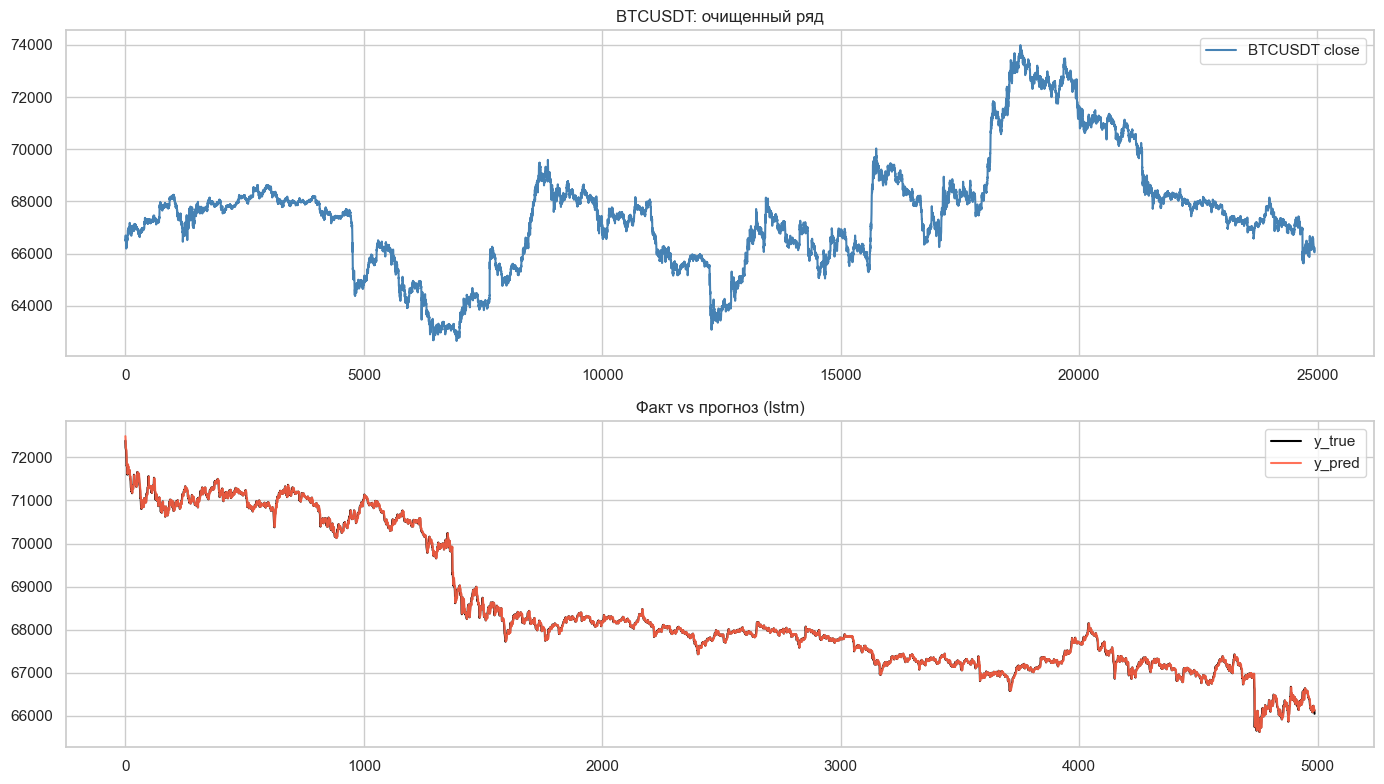

In [33]:
best_params, lstm_cv_df, model_metrics, pred_df, split_info = run_lstm_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=LSTM_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=LSTM_CV_SPLITS,
    scoring=LSTM_SCORING,
    use_cuda=LSTM_USE_CUDA,
    n_jobs=LSTM_GRID_N_JOBS,
    min_resource_points=LSTM_SEARCH_MIN_POINTS,
    max_resource_points=LSTM_SEARCH_MAX_POINTS,
    halving_factor=LSTM_HALVING_FACTOR,
    aggressive_elimination=LSTM_AGGRESSIVE_ELIMINATION,
)


ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}


TRAINED_MODELS[RUN_MODEL] = fit_lstm_inference_model(
    train,
    context_len=int(best_params['context_len']),
    hidden_size=int(best_params['hidden_size']),
    num_layers=int(best_params['num_layers']),
    dropout=float(best_params['dropout']),
    epochs=int(best_params['epochs']),
    batch_size=int(best_params['batch_size']),
    lr=float(best_params['lr']),
    weight_decay=float(best_params.get('weight_decay', 1e-4)),
    use_cuda=LSTM_USE_CUDA,
)


cv_preview_cols = [
    col for col in [
        'score',
        'score_std',
        'param_context_len',
        'param_hidden_size',
        'param_num_layers',
        'param_dropout',
        'param_epochs',
        'param_batch_size',
        'param_lr',
        'iter',
        'rank_test_score',
    ] if col in lstm_cv_df.columns
]


print('LSTM split info:', split_info)
print('LSTM best params:', best_params)
print('LSTM metrics:', model_metrics)
display(lstm_cv_df[cv_preview_cols].head(20) if cv_preview_cols else lstm_cv_df.head(20))
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

## 6) Weekly inference-only проверка



Оценка уже обученной LSTM на случайных недельных окнах без дообучения.

In [35]:
import random


import time


from concurrent.futures import ThreadPoolExecutor, as_completed




import numpy as np
import experiment_blocks as _exp
from tqdm import tqdm


_exp = importlib.reload(_exp)


if not WEEKLY_ENABLED:
    print('Weekly block disabled (WEEKLY_ENABLED=False).')
else:
    MAX_FETCH_ATTEMPTS_PER_WEEK = 20
    MAX_RANDOM_YEARS_BACK = 4
    WEEK_MINUTES = 7 * 24 * 60
    PARALLEL_WORKERS = max(2, min(12, SAFE_CPU_WORKERS))


    def _interval_to_minutes(interval_value):
        interval_str = str(interval_value).strip().upper()
        if interval_str.isdigit():
            interval_minutes = int(interval_str)
            if interval_minutes <= 0:
                raise ValueError(f'Интервал должен быть > 0, получено: {interval_value}')
            return interval_minutes
        mapping = {'D': 24 * 60, 'W': 7 * 24 * 60, 'M': 30 * 24 * 60}
        if interval_str in mapping:
            return mapping[interval_str]
        raise ValueError(f'Неподдерживаемый интервал: {interval_value}')


    INTERVAL_MINUTES = _interval_to_minutes(CONFIG.interval)
    WEEK_POINTS = max(1, (WEEK_MINUTES + INTERVAL_MINUTES - 1) // INTERVAL_MINUTES)


    if WEEKLY_RANDOM_SEED is not None:
        random.seed(int(WEEKLY_RANDOM_SEED))
        np.random.seed(int(WEEKLY_RANDOM_SEED))


    if 'lstm' not in TRAINED_MODELS:
        raise RuntimeError('LSTM модель не обучена. Сначала выполни раздел 5.')


    HISTORY_SERIES_FOR_INFERENCE = datasets[RUN_SYMBOL]['train'].astype(float).reset_index(drop=True)
    if len(HISTORY_SERIES_FOR_INFERENCE) < 80:
        raise RuntimeError(f'Слишком короткая история для inference: {len(HISTORY_SERIES_FOR_INFERENCE)}')


    print(
        f'Weekly inference window: interval={CONFIG.interval}m | '
        f'points_per_week={WEEK_POINTS} | parallel_workers={PARALLEL_WORKERS}'
    )


    def _evaluate_week(week_idx: int):
        week_raw = pd.DataFrame()
        picked_start = None
        picked_end = None
        for attempt_idx in range(1, MAX_FETCH_ATTEMPTS_PER_WEEK + 1):
            try:
                candidate = _exp._fetch_week_by_random_end(
                    base_url=CONFIG.base_url,
                    symbol=RUN_SYMBOL,
                    interval=CONFIG.interval,
                    week_hours=WEEK_POINTS,
                    max_years_back=MAX_RANDOM_YEARS_BACK,
                )
                if len(candidate) < WEEK_POINTS:
                    continue
                week_raw = candidate.iloc[-WEEK_POINTS:].copy().reset_index(drop=True)
                picked_start = week_raw['timestamp'].min()
                picked_end = week_raw['timestamp'].max()
                break
            except Exception:
                if attempt_idx >= MAX_FETCH_ATTEMPTS_PER_WEEK:
                    break
                continue


        if len(week_raw) < WEEK_POINTS:
            return {'week': week_idx + 1, 'row': None, 'info': None}


        chunk_clean, _ = processor.process(week_raw)
        test_week = chunk_clean[CONFIG.target_col].astype(float).reset_index(drop=True)
        if len(test_week) < 24:
            return {'week': week_idx + 1, 'row': None, 'info': None}


        t0 = time.perf_counter()
        metrics_week, _ = predict_lstm_inference(TRAINED_MODELS['lstm'], HISTORY_SERIES_FOR_INFERENCE, test_week)
        elapsed_sec = float(time.perf_counter() - t0)


        row = {
            'symbol': RUN_SYMBOL,
            'week': week_idx + 1,
            'start_ts': picked_start,
            'end_ts': picked_end,
            'model': 'lstm',
            'n_points': int(len(test_week)),
            'MAE': float(metrics_week['MAE']),
            'RMSE': float(metrics_week['RMSE']),
            'MAPE': float(metrics_week['MAPE']),
            'duration_sec': elapsed_sec,
        }
        info = {
            'week': week_idx + 1,
            'start_ts': picked_start,
            'end_ts': picked_end,
            'raw_points': int(len(week_raw)),
            'clean_points': int(len(test_week)),
        }
        return {'week': week_idx + 1, 'row': row, 'info': info}


    weekly_wall_t0 = time.perf_counter()
    results = []
    progress = tqdm(total=N_WEEKS_REQUESTED, desc='Weekly LSTM inference', unit='week')
    try:
        with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
            futures = {executor.submit(_evaluate_week, i): i for i in range(N_WEEKS_REQUESTED)}
            for future in as_completed(futures):
                results.append(future.result())
                progress.update(1)
    finally:
        progress.close()
    weekly_wall_sec = float(time.perf_counter() - weekly_wall_t0)


    weekly_rows = [item['row'] for item in sorted(results, key=lambda x: x['week']) if item['row'] is not None]
    weeks_info = [item['info'] for item in sorted(results, key=lambda x: x['week']) if item['info'] is not None]
    weekly_metrics_df = pd.DataFrame(weekly_rows)
    weeks_info_df = pd.DataFrame(weeks_info)


    if len(weekly_metrics_df) == 0:
        raise RuntimeError('Не удалось собрать weekly LSTM метрики.')


    weekly_summary_df = (
        weekly_metrics_df[['MAE', 'RMSE', 'MAPE', 'duration_sec']]
        .mean()
        .to_frame(name='lstm')
        .T
        .reset_index(names='model')
    )


    print(f'Weekly wall time total: {weekly_wall_sec:.2f} sec')
    display(weeks_info_df.head(20))
    display(weekly_metrics_df.head(20))
    display(weekly_summary_df)

Weekly inference window: interval=1m | points_per_week=10080 | parallel_workers=12


Weekly LSTM inference: 100%|██████████| 100/100 [07:17<00:00,  4.38s/week]

Weekly wall time total: 437.62 sec


,week,start_ts,end_ts,raw_points,clean_points
0,1,2023-01-04 07:51:00+00:00,2023-01-11 07:50:00+00:00,10080,8890
1,2,2024-09-03 15:51:00+00:00,2024-09-10 15:50:00+00:00,10080,10055
2,3,2024-01-12 08:23:00+00:00,2024-01-19 08:22:00+00:00,10080,10057
3,4,2025-04-12 23:35:00+00:00,2025-04-19 23:34:00+00:00,10080,10058
4,5,2023-04-02 11:28:00+00:00,2023-04-09 11:27:00+00:00,10080,10026
5,6,2025-01-15 20:33:00+00:00,2025-01-22 20:32:00+00:00,10080,10039
6,7,2023-06-12 12:29:00+00:00,2023-06-19 12:28:00+00:00,10080,10016
7,8,2024-05-17 12:27:00+00:00,2024-05-24 12:26:00+00:00,10080,10051
8,9,2022-07-10 08:30:00+00:00,2022-07-17 08:29:00+00:00,10080,10064
9,10,2022-04-03 08:16:00+00:00,2022-04-10 08:15:00+00:00,10080,10034


,symbol,week,start_ts,end_ts,model,n_points,MAE,RMSE,MAPE,duration_sec
0,BTCUSDT,1,2023-01-04 07:51:00+00:00,2023-01-11 07:50:00+00:00,lstm,8890,8.368302,589.783108,0.049485,43.006459
1,BTCUSDT,2,2024-09-03 15:51:00+00:00,2024-09-10 15:50:00+00:00,lstm,10055,30.267312,153.695359,0.054088,47.589774
2,BTCUSDT,3,2024-01-12 08:23:00+00:00,2024-01-19 08:22:00+00:00,lstm,10057,23.889308,267.839191,0.055350,47.476595
3,BTCUSDT,4,2025-04-12 23:35:00+00:00,2025-04-19 23:34:00+00:00,lstm,10058,32.437888,135.014796,0.038360,45.214622
4,BTCUSDT,5,2023-04-02 11:28:00+00:00,2023-04-09 11:27:00+00:00,lstm,10026,13.472059,440.797806,0.047856,47.335685
5,BTCUSDT,6,2025-01-15 20:33:00+00:00,2025-01-22 20:32:00+00:00,lstm,10039,72.604520,298.327158,0.070243,47.495052
6,BTCUSDT,7,2023-06-12 12:29:00+00:00,2023-06-19 12:28:00+00:00,lstm,10016,11.980336,465.473386,0.046257,47.480607
7,BTCUSDT,8,2024-05-17 12:27:00+00:00,2024-05-24 12:26:00+00:00,lstm,10051,28.992656,74.714166,0.042390,47.307109
8,BTCUSDT,9,2022-07-10 08:30:00+00:00,2022-07-17 08:29:00+00:00,lstm,10064,17.727684,510.009162,0.085954,47.363001
9,BTCUSDT,10,2022-04-03 08:16:00+00:00,2022-04-10 08:15:00+00:00,lstm,10034,22.532570,262.685749,0.050389,47.078952


,model,MAE,RMSE,MAPE,duration_sec
0,lstm,28.801488,300.181022,0.051879,40.397744


## 7) Экспорт артефактов



Сохраняем результаты основного LSTM-прогона и, если выполнялся weekly-блок, отдельно сохраняем weekly-таблицы.

In [ ]:
if len(ALL_RESULTS) == 0:

    raise RuntimeError('Нет результатов для экспорта. Сначала выполни обучение LSTM.')



run_dir, metrics_path, metrics_df = export_all_results(

    output_dir=OUTPUT_DIR,

    symbol=RUN_SYMBOL,

    full_series=full,

    all_results=ALL_RESULTS,

)



print('Main run saved:')

print(run_dir.resolve())

print(metrics_path.resolve())

display(metrics_df)



if 'weekly_metrics_df' in globals() and len(weekly_metrics_df) > 0:

    weekly_ts = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')

    weekly_metrics_path = OUTPUT_DIR / f'{RUN_SYMBOL}_lstm_weekly{N_WEEKS_REQUESTED}_metrics_{weekly_ts}.csv'

    weekly_summary_path = OUTPUT_DIR / f'{RUN_SYMBOL}_lstm_weekly{N_WEEKS_REQUESTED}_summary_{weekly_ts}.csv'

    weekly_weeks_path = OUTPUT_DIR / f'{RUN_SYMBOL}_lstm_weekly{N_WEEKS_REQUESTED}_weeks_{weekly_ts}.csv'



    weekly_metrics_df.to_csv(weekly_metrics_path, index=False)

    weekly_summary_df.to_csv(weekly_summary_path, index=False)

    weeks_info_df.to_csv(weekly_weeks_path, index=False)



    print('Weekly run saved:')

    print(weekly_metrics_path.resolve())

    print(weekly_summary_path.resolve())

    print(weekly_weeks_path.resolve())